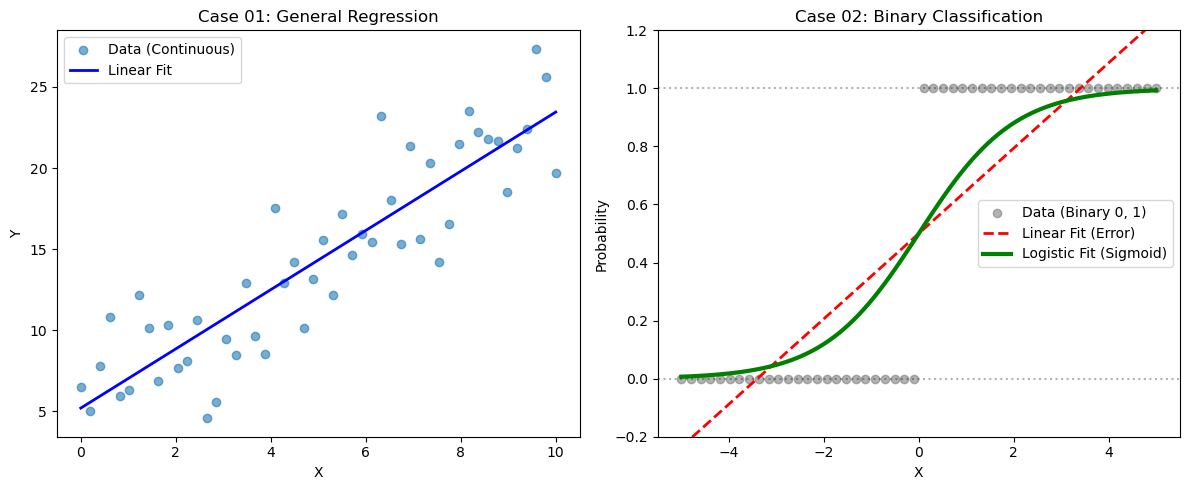

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 생성 시드 고정
np.random.seed(42)

# ---------------------------------------------------
# 1. 일반 회귀 (연속형 데이터)
# ---------------------------------------------------
x_linear = np.linspace(0, 10, 50)
y_linear = 2 * x_linear + 5 + np.random.normal(0, 3, 50)

# ---------------------------------------------------
# 2. 이진 분류 (0 또는 1 데이터)
# ---------------------------------------------------
x_binary = np.linspace(-5, 5, 50)
# 시그모이드 함수로 이진 데이터 생성
y_prob = 1 / (1 + np.exp(-x_binary))
y_binary = np.where(y_prob > 0.5, 1, 0)

# 그래프 설정 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Case 01: Linear Regression ---
axes[0].scatter(x_linear, y_linear, alpha=0.6, label='Data (Continuous)')
b1, b0 = np.polyfit(x_linear, y_linear, 1) # 선형 회귀선 계산
axes[0].plot(x_linear, b1 * x_linear + b0, color='blue', linewidth=2, label='Linear Fit')

axes[0].set_title('Case 01: General Regression')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].legend()

# --- Case 02: Binary Classification ---
axes[1].scatter(x_binary, y_binary, alpha=0.6, color='gray', label='Data (Binary 0, 1)')

# 1. 잘못된 선형 회귀 적용 (0 미만, 1 초과 발생)
b1_bin, b0_bin = np.polyfit(x_binary, y_binary, 1)
axes[1].plot(x_binary, b1_bin * x_binary + b0_bin, color='red', linestyle='--', linewidth=2, label='Linear Fit (Error)')

# 2. 올바른 로지스틱 회귀 적용 (Sigmoid 곡선, 0~1 사이 압축)
x_smooth = np.linspace(-5, 5, 100)
y_sigmoid = 1 / (1 + np.exp(-x_smooth))
axes[1].plot(x_smooth, y_sigmoid, color='green', linewidth=3, label='Logistic Fit (Sigmoid)')

# 0과 1 가이드라인
axes[1].axhline(1, color='black', linestyle=':', alpha=0.3)
axes[1].axhline(0, color='black', linestyle=':', alpha=0.3)

axes[1].set_title('Case 02: Binary Classification')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(-0.2, 1.2) # 범위를 벗어나는 빨간 점선을 보여주기 위함
axes[1].legend()

plt.tight_layout()
plt.show()

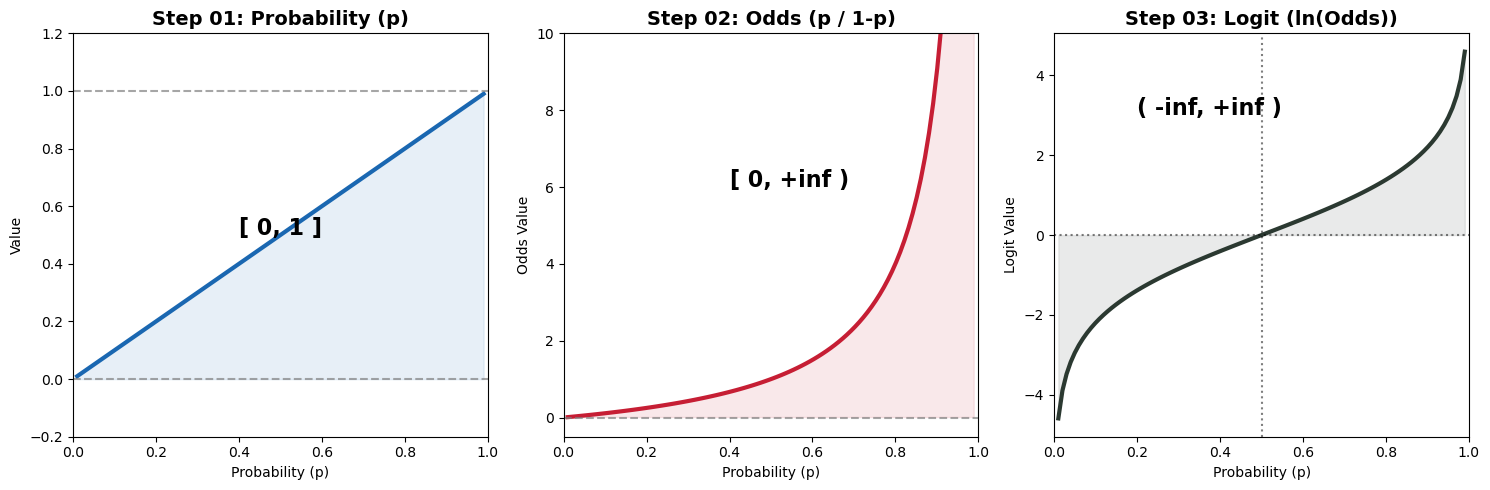

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 확률 p의 범위 설정 (0과 1은 무한대 발산을 피하기 위해 아주 약간의 여백을 둠)
p = np.linspace(0.01, 0.99, 100)

# 수학적 변환 계산
odds = p / (1 - p)
logit = np.log(odds)

# 1행 3열의 그래프 영역 생성
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ---------------------------------------------------
# Step 01: Probability (확률)
# ---------------------------------------------------
axes[0].plot(p, p, color='#1A67B1', linewidth=3)
axes[0].set_title('Step 01: Probability (p)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Probability (p)')
axes[0].set_ylabel('Value')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(-0.2, 1.2)
axes[0].axhline(1, color='gray', linestyle='--', alpha=0.7)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[0].fill_between(p, 0, p, color='#1A67B1', alpha=0.1)
axes[0].text(0.5, 0.5, '[ 0, 1 ]', fontsize=16, ha='center', fontweight='bold')

# ---------------------------------------------------
# Step 02: Odds (승산)
# ---------------------------------------------------
axes[1].plot(p, odds, color='#C61E34', linewidth=3)
axes[1].set_title('Step 02: Odds (p / 1-p)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Probability (p)')
axes[1].set_ylabel('Odds Value')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(-0.5, 10) # 승산이 급격히 증가하므로 Y축을 10으로 제한하여 형태를 보여줌
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1].fill_between(p, 0, odds, color='#C61E34', alpha=0.1)
axes[1].text(0.4, 6, '[ 0, +inf )', fontsize=16, fontweight='bold')

# ---------------------------------------------------
# Step 03: Logit (로짓)
# ---------------------------------------------------
axes[2].plot(p, logit, color='#2B3931', linewidth=3)
axes[2].set_title('Step 03: Logit (ln(Odds))', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Probability (p)')
axes[2].set_ylabel('Logit Value')
axes[2].set_xlim(0, 1)
axes[2].axhline(0, color='black', linestyle=':', alpha=0.5) # 기준선 0
axes[2].axvline(0.5, color='black', linestyle=':', alpha=0.5) # 기준선 p=0.5
axes[2].fill_between(p, logit, 0, where=(logit > 0), color='#2B3931', alpha=0.1)
axes[2].fill_between(p, logit, 0, where=(logit < 0), color='#2B3931', alpha=0.1)
axes[2].text(0.2, 3, '( -inf, +inf )', fontsize=16, fontweight='bold')

# 그래프 간격 조정 및 출력
plt.tight_layout()
plt.show()

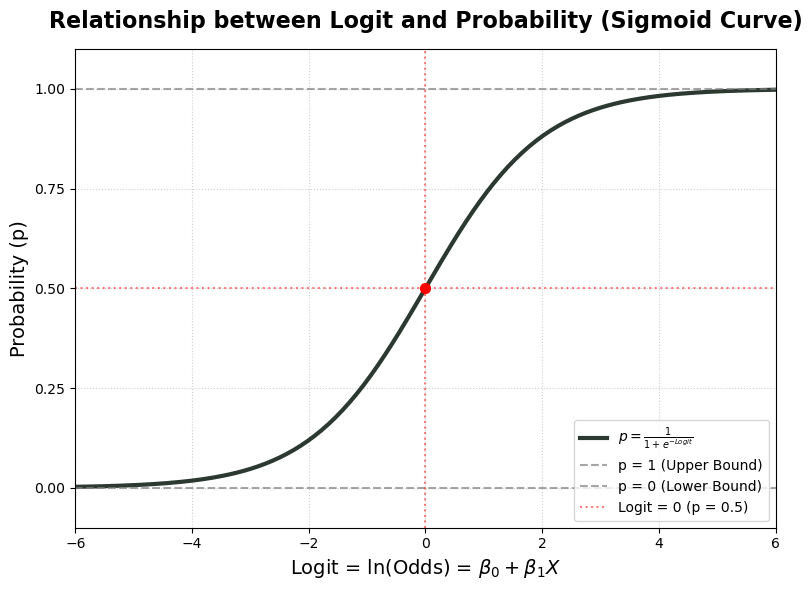

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Logit 데이터 생성 (-6부터 6까지, 무한대에 가까운 범위 시뮬레이션)
# 로짓은 음수, 양수 모두 가능하며 범위 제한이 없습니다.
logit = np.linspace(-6, 6, 200)

# 2. Probability 계산 (시그모이드 함수): p = 1 / (1 + e^(-logit))
probability = 1 / (1 + np.exp(-logit))

# 3. 그래프 그리기
plt.figure(figsize=(8, 6))

# 시그모이드 곡선
plt.plot(logit, probability, color='#2B3931', linewidth=3, label=r'$p = \frac{1}{1 + e^{-Logit}}$')

# 시각적 가이드 라인 (0과 1 수렴)
plt.axhline(1, color='gray', linestyle='--', alpha=0.7, label='p = 1 (Upper Bound)')
plt.axhline(0, color='gray', linestyle='--', alpha=0.7, label='p = 0 (Lower Bound)')

# 중심점 (Logit = 0 일 때, p = 0.5)
plt.axhline(0.5, color='red', linestyle=':', alpha=0.5)
plt.axvline(0, color='red', linestyle=':', alpha=0.5, label='Logit = 0 (p = 0.5)')
plt.scatter([0], [0.5], color='red', s=50, zorder=5) # 중심점 강조

# 축 및 레이블 설정
plt.title('Relationship between Logit and Probability (Sigmoid Curve)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Logit = ln(Odds) = $\\beta_0 + \\beta_1X$', fontsize=14)
plt.ylabel('Probability (p)', fontsize=14)

# 범위 및 눈금 설정
plt.xlim(-6, 6)
plt.ylim(-0.1, 1.1)
plt.yticks([0, 0.25, 0.5, 0.75, 1])

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [9]:
import numpy as np

# 1. Forward Pass: Linear -> Sigmoid -> MSE Loss
x = 1.0  # Input data
y = 0    # True label (binary)
w = 0.5  # Weight (example initial value)
b = -2.0 # Bias (example initial value)

# z = w*x + b
z = w * x + b
# Activation: sigmoid(z) = 1 / (1 + e^-z)
hat_y = 1.0 / (1.0 + np.exp(-z))
# Loss: MSE = (y - hat_y)^2
loss = (y - hat_y)**2

print(f"Data point (x={x}, y={y}). Prediction: {hat_y:.4f}. Loss: {loss:.4f}")

# 2. Gradient Calculation (Analytic)
# Derivative of loss w.r.t prediction: d(MSE)/d(hat_y)
# d_loss_d_hat_y = -2 * (y - hat_y)  <-- (Correcting standard form sign)
d_loss_d_hat_y = 2 * (hat_y - y) 

# Derivative of sigmoid: d(sigma)/d(z) = sigma(z) * (1 - sigma(z))
d_hat_y_d_z = hat_y * (1.0 - hat_y)

# Chain Rule to find d(Loss)/d(z)
d_loss_d_z = d_loss_d_hat_y * d_hat_y_d_z

# G gradients for parameter update: d(Loss)/d(w) = d(Loss)/d(z) * d(z)/d(w)
# (since d(z)/d(w) = x)
grad_w = d_loss_d_z * x
grad_b = d_loss_d_z * 1.0 # (since d(z)/d(b) = 1)

print(f"\nAnalytic Gradients: grad_w = {grad_w:.6f}, grad_b = {grad_b:.6f}")

# The "Trap":
# Look closely at d_loss_d_z = 2 * (hat_y - y) * hat_y * (1 - hat_y)
# Even if (hat_y - y) is large, if hat_y is close to 0 OR close to 1,
# then hat_y * (1 - hat_y) goes to ZERO. This creates the plateaus
# where learning stops, seen as the flat, trapped gradients.

Data point (x=1.0, y=0). Prediction: 0.1824. Loss: 0.0333

Analytic Gradients: grad_w = 0.054416, grad_b = 0.054416


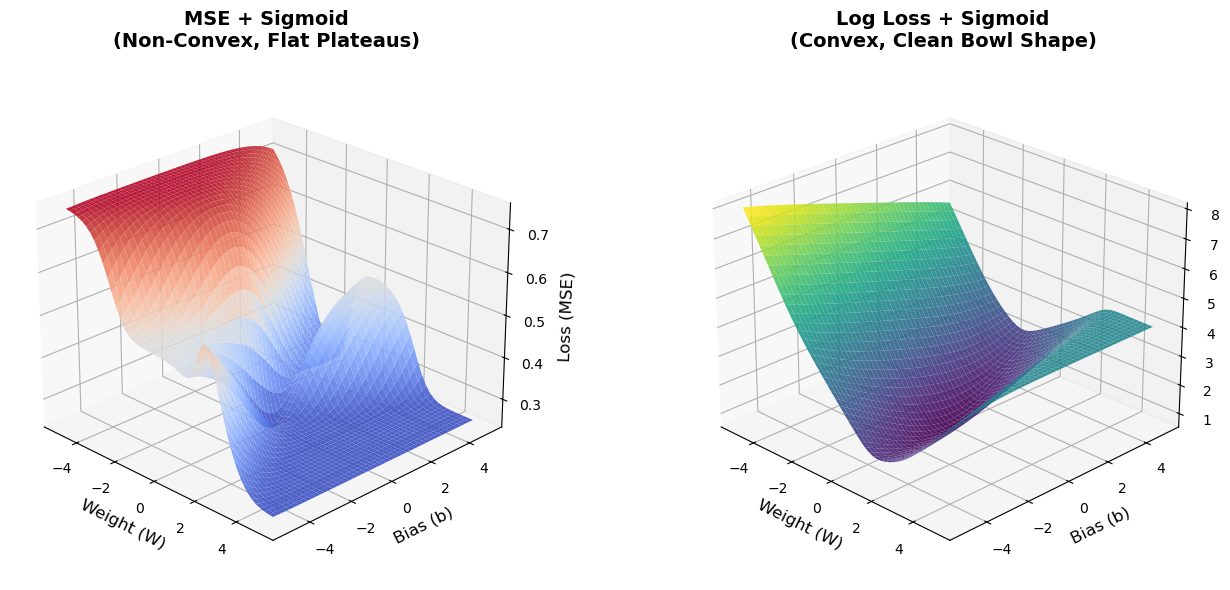

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 1. 시그모이드 및 손실 함수 정의
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def mse_loss(w, b, x, y):
    pred = sigmoid(w * x + b)
    return np.mean((pred - y)**2)

def bce_loss(w, b, x, y):
    pred = sigmoid(w * x + b)
    # 로그의 진수가 0이 되어 무한대로 발산하는 것을 막기 위해 아주 작은 값(1e-7) 추가
    return -np.mean(y * np.log(pred + 1e-7) + (1 - y) * np.log(1 - pred + 1e-7))

# 2. 가상의 이진 분류 데이터셋
# x가 -2일 때 0 (클래스 0), x가 2일 때 1 (클래스 1)
x_data = np.array([-2.0, 1.5, 2.0, 4.0])
y_data = np.array([0.0, 1.0, 1.0, 0.0])

# 3. 3D 지형도를 그리기 위한 가중치(W)와 편향(b)의 바둑판(Grid) 생성
W = np.linspace(-5, 5, 50)
B = np.linspace(-5, 5, 50)
W_grid, B_grid = np.meshgrid(W, B)

Z_mse = np.zeros_like(W_grid)
Z_bce = np.zeros_like(W_grid)

# 각 (W, b) 조합 지점에서의 Loss(고도) 계산
for i in range(W_grid.shape[0]):
    for j in range(W_grid.shape[1]):
        Z_mse[i, j] = mse_loss(W_grid[i, j], B_grid[i, j], x_data, y_data)
        Z_bce[i, j] = bce_loss(W_grid[i, j], B_grid[i, j], x_data, y_data)

# 4. 3D 그래프 그리기
fig = plt.figure(figsize=(14, 6))

# --- 왼쪽: MSE Loss 공간 ---
ax1 = fig.add_subplot(121, projection='3d')
# 붉고 푸른 색상으로 평탄한 지역과 굴곡을 강조
surf1 = ax1.plot_surface(W_grid, B_grid, Z_mse, cmap=cm.coolwarm, linewidth=0.5, antialiased=True, alpha=0.9)
ax1.set_title('MSE + Sigmoid\n(Non-Convex, Flat Plateaus)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Weight (W)', fontsize=12)
ax1.set_ylabel('Bias (b)', fontsize=12)
ax1.set_zlabel('Loss (MSE)', fontsize=12)
ax1.view_init(elev=25, azim=-45) # 굴곡이 가장 잘 보이는 각도 설정

# --- 오른쪽: Cross Entropy (Log) Loss 공간 ---
ax2 = fig.add_subplot(122, projection='3d')
# 매끄러운 밥그릇 형태를 보여주기 위해 다른 컬러맵 사용
surf2 = ax2.plot_surface(W_grid, B_grid, Z_bce, cmap=cm.viridis, linewidth=0.5, antialiased=True, alpha=0.9)
ax2.set_title('Log Loss + Sigmoid\n(Convex, Clean Bowl Shape)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Weight (W)', fontsize=12)
ax2.set_ylabel('Bias (b)', fontsize=12)
ax2.set_zlabel('Loss (Cross Entropy)', fontsize=12)
ax2.view_init(elev=25, azim=-45)

plt.tight_layout()
plt.show()

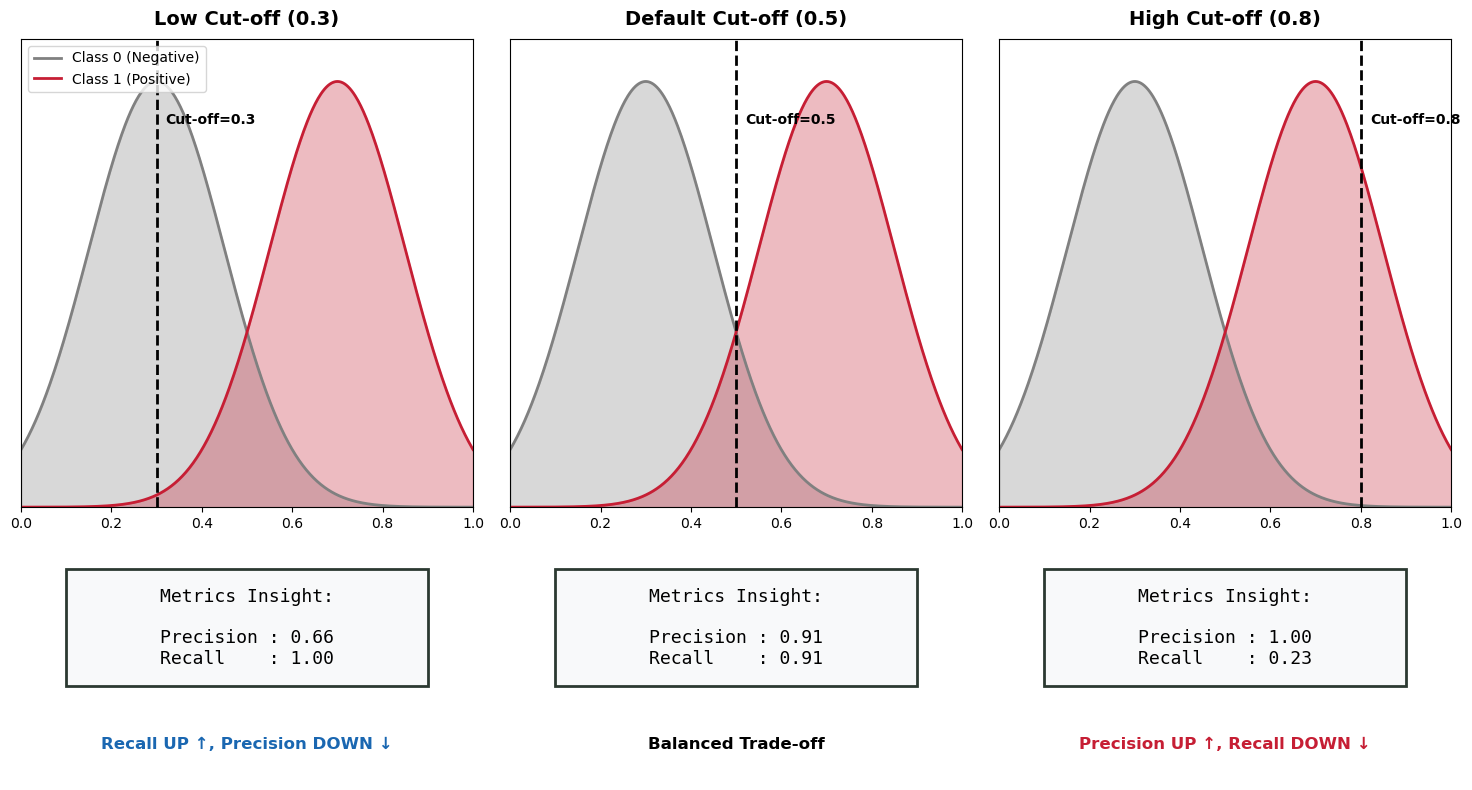

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 1. 가상의 확률 분포 데이터 생성 (클래스 0과 클래스 1)
x = np.linspace(0, 1, 500)
# Class 0 (Negative)는 0.3 부근에, Class 1 (Positive)은 0.7 부근에 밀집
pdf_class0 = np.exp(-0.5 * ((x - 0.3) / 0.15)**2)
pdf_class1 = np.exp(-0.5 * ((x - 0.7) / 0.15)**2)

# 2. Cut-off 시나리오 3가지
thresholds = [0.3, 0.5, 0.8]
titles = ['Low Cut-off (0.3)', 'Default Cut-off (0.5)', 'High Cut-off (0.8)']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), gridspec_kw={'height_ratios': [2, 1]})
plt.subplots_adjust(hspace=0.3)

for i, threshold in enumerate(thresholds):
    # --- Top Row: 확률 분포와 Cut-off 기준선 ---
    ax_dist = axes[0, i]
    ax_dist.plot(x, pdf_class0, color='gray', linewidth=2, label='Class 0 (Negative)')
    ax_dist.plot(x, pdf_class1, color='#C61E34', linewidth=2, label='Class 1 (Positive)')
    
    ax_dist.fill_between(x, pdf_class0, color='gray', alpha=0.3)
    ax_dist.fill_between(x, pdf_class1, color='#C61E34', alpha=0.3)
    
    # Cut-off 라인
    ax_dist.axvline(threshold, color='black', linestyle='--', linewidth=2)
    ax_dist.text(threshold + 0.02, 0.9, f'Cut-off={threshold}', fontweight='bold')
    
    ax_dist.set_title(titles[i], fontsize=14, fontweight='bold', pad=10)
    ax_dist.set_xlim(0, 1)
    ax_dist.set_ylim(0, 1.1)
    ax_dist.set_yticks([])
    if i == 0:
        ax_dist.legend(loc='upper left')
        
    # --- Bottom Row: 간소화된 혼동 행렬 및 지표 ---
    ax_matrix = axes[1, i]
    ax_matrix.axis('off')
    
    # 시각적 지표 계산 (분포 면적 기반 비율)
    tp_area = np.sum(pdf_class1[x >= threshold])
    fn_area = np.sum(pdf_class1[x < threshold])
    fp_area = np.sum(pdf_class0[x >= threshold])
    
    precision = tp_area / (tp_area + fp_area) if (tp_area + fp_area) > 0 else 1.0
    recall = tp_area / (tp_area + fn_area) if (tp_area + fn_area) > 0 else 0.0
    
    # 박스 그리기
    box_color = '#2B3931'
    ax_matrix.add_patch(Rectangle((0.1, 0.4), 0.8, 0.5, facecolor='#f8f9fa', edgecolor=box_color, lw=2))
    
    metrics_text = (
        f"Metrics Insight:\n\n"
        f"Precision : {precision:.2f}\n"
        f"Recall    : {recall:.2f}"
    )
    
    # 트레이드오프 강조 텍스트
    if i == 0:
        highlight = "Recall UP ↑, Precision DOWN ↓"
        h_color = '#1A67B1'
    elif i == 2:
        highlight = "Precision UP ↑, Recall DOWN ↓"
        h_color = '#C61E34'
    else:
        highlight = "Balanced Trade-off"
        h_color = 'black'

    ax_matrix.text(0.5, 0.65, metrics_text, fontsize=13, ha='center', va='center', family='monospace')
    ax_matrix.text(0.5, 0.15, highlight, fontsize=12, fontweight='bold', color=h_color, ha='center', va='center')

plt.tight_layout()
plt.show()